In [ ]:
# Import the tuecycle package
from tuecycle.data import DataManager
from tuecycle.config import list_stations_with_weather
from tuecycle.plots import get_plot, list_plots
import pandas as pd


START_DATE = (2022, 12, 1)
END_DATE = (2025, 11, 30)

WORKDAY_HOURS = list(range(6, 19))
LEISURE_HOURS = list(range(10, 19))
MAXLAGS = 8

# Stations to load
STATIONS = [station for station in list_stations_with_weather()]

# Initialize the DataManager
dm = DataManager(start_date=START_DATE,
                 end_date=END_DATE)
# Load all comparison stations at once using the configuration
dfs = dm.get_multiple(STATIONS)

# Remove visual outliers
VISUAL_OUTLIERS = [
    ("freiburg_eschholz", "2025-04-06 11:00:00"),
    
    ("freiburg_wiwili", "2025-01-30 17:00:00"),
    ("freiburg_wiwili", "2025-01-30 18:00:00"),
    ("freiburg_wiwili", "2025-01-30 19:00:00"), 
    
    ("heidelberg_ploeck", "2025-04-27 08:00:00"),
    
    ("karlsruhe_erbprinzen", "2023-03-28 08:00:00"),
    ("karlsruhe_erbprinzen", "2024-06-07 19:00:00"),
    
    ("kirchheim_barometer", "2022-12-19 19:00:00"),
    
    ("loerrach_berliner", "2023-02-27 17:00:00"),
    
    ("loerrach_friedhof", "2023-05-24 21:00:00"),
    
    # ("mannheim_feudenheimstr_aus", "2024-01-27 17:00:00"),
    
    # ("mannheim_feudenheimstr_ein", "2024-01-27 15:00:00"),
    
    ("mannheim_schlosspark", "2025-06-27 09:00:00"),
    ("mannheim_schlosspark", "2024-06-12 09:00:00"),
    
    ("ravensburg_meer_auf", "2025-11-12 22:00:00"),
    ("ravensburg_meer_auf", "2023-08-20 23:00:00"),
    ("ravensburg_meer_auf", "2024-03-02 17:00:00"),
    
    # ("stuttgart_kremmler", "2024-09-15 10:00:00"),
    # ("stuttgart_kremmler", "2024-09-15 11:00:00"),
    # ("stuttgart_kremmler", "2024-09-15 12:00:00"),
    # ("stuttgart_kremmler", "2024-09-15 13:00:00"),
    
    # ("stuttgart_solitude", "2023-10-08 15:00:00"),
    # ("stuttgart_solitude", "2025-07-04 21:00:00"),
    
    ## ("stuttgart_waiblinger", "2023-12-21 09:00:00"),
    ## ("stuttgart_waiblinger", "2023-12-21 10:00:00"),
    ## ("stuttgart_waiblinger", "2025-09-21 16:00:00"),
    
    ("tuebingen_steinlach", "2025-03-19 14:00:00"),
]

for alias, timestamp in VISUAL_OUTLIERS:
    df = dfs[alias]
    df.loc[df["datetime"] == timestamp, 'bike'] = None
print("Visual outliers removed.\n")

# Remove days with more than ten 0 counts
for alias, df in dfs.items():
    # Count zero bike counts per day
    df['date'] = df['datetime'].dt.date
    zero_counts_per_day = df.groupby('date')['bike'].apply(lambda x: (x == 0).sum())
        
    # Identify faulty days
    faulty_days = zero_counts_per_day[zero_counts_per_day > 10].index
        
    # Remove faulty days
    for day in faulty_days:
        df.loc[df['date'] == day, 'bike'] = None
        
    # Drop the temporary 'date' column
    df.drop(columns=['date'], inplace=True)
print("Faulty days removed.\n")

# Remove Heilbronn Neckarufer outlier period (2025-10-26 00:00:00 - 2025-10-30 00:00:00)
alias = "heilbronn_neckarufer"
df = dfs[alias]
start_outlier = pd.to_datetime("2025-10-26 00:00:00")
end_outlier = pd.to_datetime("2025-10-30 00:00:00")
df.loc[(df["datetime"] >= start_outlier) & (df["datetime"] <= end_outlier), 'bike'] = None
print(f"Station {alias} - Heilbronn Neckarufer outlier period removed.\n")

# Add stations with more than 10% missing values to excluded stations
excluded_stations = []
for alias, df in dfs.items():
    missing_values = df['bike'].isna().sum()
    total_values = len(df)
    if (missing_values / total_values) > 0.1:
        excluded_stations.append(alias)
        
# Now exclude these stations from further analysis
for alias in excluded_stations:
    del dfs[alias]
print("Excluded stations with more than 10% missing values.\n")

print(f"\nData cleaning completed. Stations remaining for analysis: {len(dfs.keys())}")
STATIONS = dfs.keys()
for alias in dfs.keys():
    print(f"- {alias}")

Visual outliers removed.

Faulty days removed.

Station heilbronn_neckarufer - Heilbronn Neckarufer outlier period removed.

Excluded stations with more than 10% missing values.


Data cleaning completed. Stations remaining for analysis: 37
- freiburg_eschholz
- freiburg_gueterbahn
- freiburg_wiwili
- heidelberg_eppelheimer
- heidelberg_ploeck
- heidelberg_theodor_heuss
- heilbronn_neckarufer
- heilbronn_nord
- karlsruhe_erbprinzen
- kirchheim_barometer
- konstanz_herose
- loerrach_berliner
- loerrach_friedhof
- ludwigsburg_alleen
- ludwigsburg_favorite
- mannheim_konrad_adenauer
- mannheim_kurpfalz
- mannheim_luzenberg
- mannheim_renz
- mannheim_schlosspark
- mannheim_schwetzinger
- ravensburg_bahnhof
- ravensburg_eishalle
- ravensburg_meer_ab
- ravensburg_meer_auf
- stuttgart_insel
- stuttgart_koenig_karls
- stuttgart_kraeherwald
- stuttgart_lautenschlager
- stuttgart_samara
- stuttgart_stuttgarter
- stuttgart_taubenheim
- stuttgart_waiblinger
- stuttgart_tuebinger
- tuebingen_tunnel

In [36]:
import numpy as np

# Combine raw bike counts per city, then standardize once at city level
cities = set(alias.split('_')[0] for alias in STATIONS)
city_dfs = {}
for city in cities:
    city_dfs[city] = pd.DataFrame()
    city_dfs[city]['datetime'] = dfs[next(iter(dfs))]['datetime']
    
    # Average raw bike counts
    bike_counts = pd.concat(
        [dfs[alias]['bike'] for alias in STATIONS if alias.startswith(city)],
        axis=1
    )
    # and only keep rows where ALL counters have values
    city_dfs[city]['bike'] = bike_counts.mean(axis=1, skipna=False)
    
    # Standardize at city level to remove position bias and keep relative changes
    city_dfs[city]['standardized_bike_count'] = (
        (city_dfs[city]['bike'] - city_dfs[city]['bike'].mean()) / 
        city_dfs[city]['bike'].std()
    )
    
    # Add logged bike counts
    city_dfs[city]['logged_bike_count'] = np.log1p(city_dfs[city]['bike'])
    
    # Also average weather data
    city_dfs[city]['temp'] = pd.concat(
        [dfs[alias]['temp'] for alias in STATIONS if alias.startswith(city)],
        axis=1
    ).mean(axis=1, skipna=False)
    city_dfs[city]['rain'] = pd.concat(
        [dfs[alias]['rain'] for alias in STATIONS if alias.startswith(city)],
        axis=1
    ).mean(axis=1, skipna=False)

# For each city print the amount of missing values in bike
for city in cities:
    missing_count = city_dfs[city]['bike'].isna().sum()
    total_count = len(city_dfs[city])
    print(f"{city.capitalize()} – missing bike values: {missing_count} out of {total_count} ({(missing_count/total_count)*100:.2f}%)")
    

Loerrach – missing bike values: 234 out of 26304 (0.89%)
Tuebingen – missing bike values: 1860 out of 26304 (7.07%)
Freiburg – missing bike values: 802 out of 26304 (3.05%)
Heidelberg – missing bike values: 2292 out of 26304 (8.71%)
Heilbronn – missing bike values: 1671 out of 26304 (6.35%)
Karlsruhe – missing bike values: 275 out of 26304 (1.05%)
Kirchheim – missing bike values: 77 out of 26304 (0.29%)
Konstanz – missing bike values: 220 out of 26304 (0.84%)
Ludwigsburg – missing bike values: 76 out of 26304 (0.29%)
Ravensburg – missing bike values: 2770 out of 26304 (10.53%)
Stuttgart – missing bike values: 511 out of 26304 (1.94%)
Ulm – missing bike values: 814 out of 26304 (3.09%)
Mannheim – missing bike values: 1863 out of 26304 (7.08%)


In [37]:
# Print average bike counts per city
for city in cities:
    avg_bike_count = city_dfs[city]['bike'].mean()
    print(f"Average bike count in {city.capitalize()}: {avg_bike_count:.2f}")

Average bike count in Loerrach: 35.64
Average bike count in Tuebingen: 241.57
Average bike count in Freiburg: 236.60
Average bike count in Heidelberg: 170.51
Average bike count in Heilbronn: 44.81
Average bike count in Karlsruhe: 179.76
Average bike count in Kirchheim: 36.19
Average bike count in Konstanz: 389.55
Average bike count in Ludwigsburg: 81.74
Average bike count in Ravensburg: 21.04
Average bike count in Stuttgart: 49.59
Average bike count in Ulm: 45.19
Average bike count in Mannheim: 96.55


In [38]:
# Public holidays in baden-wuerttemberg
public_holidays = [
    "2022-12-25",
    "2022-12-26",
    "2023-01-01",
    "2023-01-06",
    "2023-04-07",
    "2023-04-10",
    "2023-05-01",
    "2023-05-18",
    "2023-05-29",
    "2023-06-08",
    "2023-10-03",
    "2023-11-01",
    "2023-12-25",
    "2023-12-26",
    "2024-01-01",
    "2024-01-06",
    "2024-03-29",
    "2024-04-01",
    "2024-05-01",
    "2024-05-09",
    "2024-05-20",
    "2024-05-30",
    "2024-10-03",
    "2024-11-01",
    "2024-12-25",
    "2024-12-26",
    "2025-01-01",
    "2025-01-06",
    "2025-04-18",
    "2025-04-21",
    "2025-05-01",
    "2025-05-29",
    "2025-06-09",
    "2025-06-19",
    "2025-10-03",
    "2025-11-01"
]


# school holidays in baden-wuerttemberg (start date, end date) (inclusive)
school_holidays = [ 
    ("2022-12-21", "2023-01-08"),
    ("2023-04-06", "2023-04-16"),
    ("2023-05-27", "2023-06-11"),
    ("2023-07-27", "2023-09-10"),
    ("2023-10-30", "2023-11-05"),
    ("2023-12-23", "2024-01-07"),
    ("2024-03-23", "2024-04-07"),
    ("2024-05-18", "2024-06-02"),
    ("2024-07-25", "2024-09-08"),
    ("2024-10-26", "2024-11-03"),
    ("2024-12-21", "2025-01-05"),
    ("2025-04-12", "2025-04-27"),
    ("2025-06-07", "2025-06-22"),
    ("2025-07-31", "2025-09-14"),
    ("2025-10-25", "2025-11-02")]

# semester holidays for biggest university in each city
lecture_free_periods = {
    "freiburg": [("2022-12-23", "2023-01-08"),
                 ("2023-02-11", "2023-04-16"), 
                 ("2023-05-27", "2023-06-04"), 
                 ("2023-07-22", "2023-10-15"),
                 ("2023-12-23", "2024-01-07"), 
                 ("2024-02-10", "2024-04-14"),
                 ("2024-05-18", "2024-05-26"), 
                 ("2024-07-27", "2024-10-14"),
                 ("2024-12-21", "2025-01-06"),
                 ("2025-02-08", "2025-04-13"),
                 ("2025-06-07", "2025-06-15"),
                 ("2025-07-19", "2025-10-12")],
    "heidelberg": [("2022-12-22", "2023-01-08"),
                   ("2023-02-18", "2023-04-16"),
                   ("2023-07-29", "2023-10-15"),
                   ("2023-12-21", "2024-01-07"),
                   ("2024-02-10", "2024-04-14"),
                   ("2024-07-27", "2024-10-13"),
                   ("2024-12-21", "2025-01-06"),
                   ("2025-02-08", "2025-04-13"),
                   ("2025-07-26", "2025-10-12")],
    "heilbronn": [("2022-12-24", "2023-01-08"),
                  ("2023-01-21", "2023-03-12"),
                  ("2023-05-27", "2023-06-04"),
                  ("2023-07-01", "2023-09-24"), # end estimated
                  ("2023-12-23", "2024-01-07"), # christmas break estimated
                  ("2024-01-20", "2024-03-10"), # start estimated
                  ("2024-05-18", "2024-05-24"),
                  ("2024-06-29", "2024-09-22"),
                  ("2024-12-21", "2025-01-06"),
                  ("2025-01-18", "2025-03-09"),
                  ("2025-06-07", "2025-06-15"),
                  ("2025-06-28", "2025-09-21")],
    "karlsruhe": [("2022-12-24", "2023-01-08"),
                  ("2023-02-18", "2023-04-16"),
                  ("2023-05-27", "2023-06-04"),
                  ("2023-07-29", "2023-10-22"),
                  ("2023-12-23", "2024-01-07"),
                  ("2024-02-17", "2024-04-14"),
                  ("2024-05-18", "2024-05-26"),
                  ("2024-07-27", "2024-10-20"),
                  ("2024-12-23", "2025-01-06"), # educated guess
                  ("2025-02-15", "2025-04-21"),
                  ("2025-06-07", "2025-06-15"),
                  ("2025-08-02", "2025-10-26")],
    "kirchheim": [], # no university
    "konstanz": [("2022-12-24", "2023-01-08"),
                 ("2023-02-11", "2023-04-10"),
                 ("2023-06-03", "2023-06-11"),
                 ("2023-07-22", "2023-10-22"),
                 ("2023-12-23", "2024-01-07"),
                 ("2024-02-10", "2024-04-07"),
                 ("2024-05-25", "2024-06-02"),
                 ("2024-07-20", "2024-10-20"),
                 ("2024-12-21", "2025-01-06"),
                 ("2025-02-08", "2025-04-06"),
                 ("2025-06-14", "2025-06-22"),
                 ("2025-07-19", "2025-10-19")],
    "loerrach": [], # only dual study programs - no semester breaks
    "ludwigsburg": [("2022-12-24", "2023-01-08"),
                    ("2023-02-04", "2023-04-10"),
                    ("2023-05-27", "2023-06-04"),
                    ("2023-07-22", "2023-10-15"),
                    ("2023-12-23", "2024-01-07"),
                    ("2024-02-03", "2024-04-07"),
                    ("2024-05-18", "2024-05-26"),
                    ("2024-07-20", "2024-10-13"),
                    ("2024-12-21", "2025-01-06"),
                    ("2025-02-01", "2025-04-06"),
                    ("2025-06-07", "2025-06-15"),
                    ("2025-07-26", "2025-10-19")],
    "mannheim": [("2022-12-17", "2023-01-08"),
                 ("2023-01-28", "2023-03-19"),
                 ("2023-07-15", "2023-09-21"),
                 ("2023-12-23", "2024-01-07"),
                 ("2024-01-20", "2024-03-17"),
                 ("2024-07-13", "2024-09-22"),
                 ("2024-12-21", "2025-01-06"),
                 ("2025-01-18", "2025-03-16"), 
                 ("2025-07-12", "2025-09-21")],
    "ravensburg": [("2022-12-24", "2023-01-08"),
                   ("2023-01-28", "2023-03-12"),
                   ("2023-04-06", "2023-04-11"),
                   ("2023-05-27", "2023-06-04"),
                   ("2023-07-01", "2023-10-03"),
                   ("2023-12-23", "2024-01-07"),
                   ("2024-01-27", "2024-03-10"),
                   ("2024-03-28", "2024-04-02"),
                   ("2024-05-18", "2024-05-26"),
                   ("2024-06-29", "2024-10-06"),
                   ("2024-12-21", "2025-01-06"),
                   ("2025-02-01", "2025-03-16"),
                   ("2025-04-17", "2025-04-22"),
                   ("2025-06-07", "2025-06-15"),
                   ("2025-07-05", "2025-10-05")],
    "stuttgart": [("2022-12-24", "2023-01-08"), # educated guess
                  ("2023-02-04", "2023-04-10"), # start estimated
                  ("2023-05-27", "2023-06-04"),
                  ("2023-07-22", "2023-10-15"),
                  ("2023-12-23", "2024-01-07"), 
                  ("2024-02-10", "2024-04-07"),
                  ("2024-05-18", "2024-05-26"),
                  ("2024-07-20", "2024-10-13"),
                  ("2024-12-21", "2025-01-06"),
                  ("2025-02-08", "2025-04-06"),
                  ("2025-06-07", "2025-06-15"),
                  ("2025-07-19", "2025-10-12")],
    "tuebingen": [("2022-12-24", "2023-01-08"),
                  ("2023-02-11", "2023-04-16"),
                  ("2023-05-27", "2023-06-04"),
                  ("2023-07-29", "2023-10-15"),
                  ("2023-12-23", "2024-01-07"),
                  ("2024-02-10", "2024-04-14"),
                  ("2024-05-18", "2024-05-26"),
                  ("2024-07-27", "2024-10-13"),
                  ("2024-12-21", "2025-01-06"),
                  ("2025-02-08", "2025-04-13"),
                  ("2025-06-07", "2025-06-15"),
                  ("2025-07-26", "2025-10-12")],
    "ulm": [("2022-12-24", "2023-01-08"),
            ("2023-02-18", "2023-04-16"),
            ("2023-07-22", "2023-10-15"),
            ("2023-12-23", "2024-01-07"),
            ("2024-02-17", "2024-04-14"),
            ("2024-07-20", "2024-10-13"),
            ("2024-12-24", "2025-01-06"),
            ("2025-02-15", "2025-04-21"),
            ("2025-07-26", "2025-10-12")]
                    
}


# Add important feature to each city's dataframe
for city in cities:
    city_dfs[city]['date'] = city_dfs[city]['datetime'].dt.date
    city_dfs[city]['day_of_week'] = city_dfs[city]['datetime'].dt.dayofweek  # Monday=0, Sunday=6
    city_dfs[city]['is_public_holiday'] = city_dfs[city]['date'].astype(str).isin(public_holidays).astype(int)
    
    # Workday and Non-Workday indicators
    city_dfs[city]['is_workday'] = (
        (city_dfs[city]['day_of_week'] < 5) &   # Monday to Friday
        (~city_dfs[city]['is_public_holiday'])  # Not a public holiday
    ).astype(int)
    city_dfs[city]['is_non_workday'] = (
        (city_dfs[city]['is_workday'] == 0)
    ).astype(int)
    
    # Leisure hour indicator (Saturday and Sunday from LEISURE_HOURS)
    city_dfs[city]['is_leisure'] = (
        ((city_dfs[city]['day_of_week'] == 5) | (city_dfs[city]['day_of_week'] == 6)) &  # Saturday or Sunday
        (city_dfs[city]['datetime'].dt.hour.isin(LEISURE_HOURS))
    ).astype(int)
    
    # Add semester break indicator
    lecture_free = lecture_free_periods.get(city, [])
    city_dfs[city]['is_lecture_free'] = 0
    for start_str, end_str in lecture_free:
        start_date = pd.to_datetime(start_str).date()
        end_date = pd.to_datetime(end_str).date()
        city_dfs[city]['is_lecture_free'] |= city_dfs[city]['date'].apply(
            lambda d: 1 if start_date <= d <= end_date else 0
        )
    
    # Add school holiday indicator
    city_dfs[city]['is_school_holiday'] = 0
    for start_str, end_str in school_holidays:
        start_date = pd.to_datetime(start_str).date()
        end_date = pd.to_datetime(end_str).date()
        city_dfs[city]['is_school_holiday'] |= city_dfs[city]['date'].apply(
            lambda d: 1 if start_date <= d <= end_date else 0
        )
    
    # Add hour, month, year features
    city_dfs[city]['hour'] = city_dfs[city]['datetime'].dt.hour
    city_dfs[city]['month'] = city_dfs[city]['datetime'].dt.month
    city_dfs[city]['year'] = city_dfs[city]['datetime'].dt.year
    
    # Drop temporary column
    city_dfs[city].drop(columns=['date'], inplace=True)


In [39]:
# Log-linear regression 
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
results = {}

leisure_dfs = {}
for city in cities:
    leisure_dfs[city] = city_dfs[city][city_dfs[city]['is_leisure'] == 1]

r_squared_values = {}
for city in cities:
    df = leisure_dfs[city].dropna(subset=['logged_bike_count', 'rain', 'temp'])

    # Build X with rain, temp, and hour dummies
    X = df[['rain', 'temp']].copy()
    X = X.astype(float)
    
    # Fixed Effects: hour, month, lecture_free, school_holiday
    fe_hour  = pd.get_dummies(df['hour'],  prefix='hour',  drop_first=True, dtype=float)
    fe_month = pd.get_dummies(df['month'], prefix='month', drop_first=True, dtype=float)
    fe_lecture_free = df['is_lecture_free'].astype(float)
    fe_school_holiday = df['is_school_holiday'].astype(float)
    
    # Combine all regressors
    X = pd.concat([X, fe_month, fe_hour, fe_lecture_free, fe_school_holiday], axis=1)
    
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    y = df['logged_bike_count'].astype(float)
    
    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': MAXLAGS}
    )

    results[city] = model
    print(f"\nLog-linear regression results for {city.capitalize()}:")
    print(model.summary())
    
    r_squared_values[city] = model.rsquared 

    
print("Average R-squared for leisure hour log-linear models:",
      np.mean(list(r_squared_values.values())))
print("\nR-squared values for log-linear regression models during leisure hours:")
for city, r2 in r_squared_values.items():
    print(f"- {city.capitalize()}: R² = {r2:.4f}")
    
# rain, temp, month FE, hour FE
# Average R-squared for leisure hour log-linear models: 0.4875594889997651

#                                + lec_free    + holiday    + both
# - Stuttgart: R² =     0.6668      0.6703      0.6783      0.6787
# - Heidelberg: R² =    0.2992      0.3359      0.3651      0.3789
# - Kirchheim: R² =     0.3127      0.3127      0.3230      0.3230
# - Ludwigsburg: R² =   0.4940      0.5048      0.5313      0.5317
# - Loerrach: R² =      0.4759      0.4759      0.4893      0.4893
# - Tuebingen: R² =     0.4370      0.4668      0.4667      0.4761
# - Freiburg: R² =      0.4252      0.4514      0.4727      0.4779
# - Ulm: R² =           0.6781      0.6829      0.6868      0.6890
# - Ravensburg: R² =    0.5729      0.5769      0.5858      0.5858
# - Konstanz: R² =      0.5666      0.5769      0.5898      0.5919
# - Heilbronn: R² =     0.6703      0.6724      0.6803      0.6805
# - Mannheim: R² =      0.5324      0.5326      0.5481      0.5492
# - Karlsruhe: R² =     0.2071      0.2252      0.2426      0.2446


Log-linear regression results for Loerrach:
                            OLS Regression Results                            
Dep. Variable:      logged_bike_count   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.513
Method:                 Least Squares   F-statistic:                     53.22
Date:                Mon, 02 Feb 2026   Prob (F-statistic):          4.88e-193
Time:                        15:58:59   Log-Likelihood:                -1276.1
No. Observations:                2781   AIC:                             2598.
Df Residuals:                    2758   BIC:                             2735.
Df Model:                          22                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/Users/katrinwillger/Studium/Data Literacy/tuecycle/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/katrinwillger/Studium/Data Literacy/tuecycle/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 22
  warnings.warn('covariance of constraints does not have full '
/Users/katrinwillger/Studium/Data Literacy/tuecycle/.venv/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/katrinwillger/Studium/Data Literacy/tuecycle/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 23, but rank is 22
  warn


Log-linear regression results for Stuttgart:
                            OLS Regression Results                            
Dep. Variable:      logged_bike_count   R-squared:                       0.689
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     87.37
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:59:00   Log-Likelihood:                -927.31
No. Observations:                2718   AIC:                             1903.
Df Residuals:                    2694   BIC:                             2044.
Df Model:                          23                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

## HAC Standard Errors and `maxlags` Parameter

**What are HAC Standard Errors?**
- HAC = Heteroskedasticity and Autocorrelation Consistent (also called Newey-West standard errors)
- They correct for:
  1. **Heteroskedasticity**: Error variance changes over observations
  2. **Autocorrelation**: Errors are correlated across time (e.g., a rainy hour often follows another rainy hour)

**Why do we need them?**
- Hourly bike count data is time series data with natural autocorrelation
- Without correction, standard errors would be **underestimated** → confidence intervals too narrow → false sense of precision
- HAC errors give more realistic uncertainty estimates

**What does `maxlags=8` mean?**
- It specifies the maximum number of time lags to include when estimating autocorrelation
- `maxlags=8` means we account for correlations up to 8 hours apart
- The Newey-West estimator downweights correlations as lags increase (using a Bartlett kernel)

**Impact of maxlags size:**
- **Too small** (e.g., maxlags=1-2): May miss longer-range autocorrelation → still underestimated SEs
- **Too large** (e.g., maxlags=50): Includes noise, less efficient → overly conservative SEs
- **Rule of thumb**: $maxlags \\approx 4 \\times (T/100)^{2/9}$ where T = sample size
  - For our data (~1000-2000 hourly observations), this suggests maxlags ≈ 6-8
- **8 hours** is reasonable because:
  - Captures within-day autocorrelation (weather persistence)
  - Typical weather system duration
  - Not so large as to include irrelevant noise

**Sensitivity check**: You could try maxlags=4, 8, 12 to see if coefficients/p-values change substantially. If they're stable, the choice is robust.

In [40]:
# Sensitivity analysis: Impact of maxlags on standard errors
# Test for Tübingen leisure hours as an example

test_city = 'tuebingen'
df = leisure_dfs[test_city].dropna(subset=['logged_bike_count', 'rain', 'temp'])

X = df[['rain', 'temp']].copy()
X = X.astype(float)

fe_hour  = pd.get_dummies(df['hour'],  prefix='hour',  drop_first=True, dtype=float)
fe_month = pd.get_dummies(df['month'], prefix='month', drop_first=True, dtype=float)
fe_lecture_free = df['is_lecture_free'].astype(float)
fe_school_holiday = df['is_school_holiday'].astype(float)

X = pd.concat([X, fe_month, fe_hour, fe_lecture_free, fe_school_holiday], axis=1)
X = sm.add_constant(X)
y = df['logged_bike_count'].astype(float)

# Test different maxlags values
maxlags_values = [4,7,8,9,10,11,12, 16]
results_comparison = {}

print(f"Sensitivity Analysis for {test_city.capitalize()} (Leisure Hours)")
print("="*80)

for maxlags in maxlags_values:
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    results_comparison[maxlags] = model
    
    rain_coef = model.params['rain']
    rain_se = model.bse['rain']
    rain_pval = model.pvalues['rain']
    
    temp_coef = model.params['temp']
    temp_se = model.bse['temp']
    temp_pval = model.pvalues['temp']
    
    print(f"\nmaxlags = {maxlags}:")
    print(f"  Rain:  coef = {rain_coef:.6f}, SE = {rain_se:.6f}, p-value = {rain_pval:.4f}")
    print(f"  Temp:  coef = {temp_coef:.6f}, SE = {temp_se:.6f}, p-value = {temp_pval:.4f}")

# Also compare with standard OLS (no HAC correction)
model_ols = sm.OLS(y, X).fit()
print(f"\nStandard OLS (no HAC correction):")
print(f"  Rain:  coef = {model_ols.params['rain']:.6f}, SE = {model_ols.bse['rain']:.6f}, p-value = {model_ols.pvalues['rain']:.4f}")
print(f"  Temp:  coef = {model_ols.params['temp']:.6f}, SE = {model_ols.bse['temp']:.6f}, p-value = {model_ols.pvalues['temp']:.4f}")

print("\n" + "="*80)
print("Key observations:")
print("- Coefficients remain identical (only SEs change)")
print("- HAC SEs are larger than standard OLS SEs (accounting for autocorrelation)")
print("- Results are relatively stable across reasonable maxlags values (4-16)")
print("- maxlags=8 is a good middle ground")

Sensitivity Analysis for Tuebingen (Leisure Hours)

maxlags = 4:
  Rain:  coef = -0.106845, SE = 0.029870, p-value = 0.0003
  Temp:  coef = 0.035180, SE = 0.003111, p-value = 0.0000

maxlags = 7:
  Rain:  coef = -0.106845, SE = 0.030775, p-value = 0.0005
  Temp:  coef = 0.035180, SE = 0.003525, p-value = 0.0000

maxlags = 8:
  Rain:  coef = -0.106845, SE = 0.031034, p-value = 0.0006
  Temp:  coef = 0.035180, SE = 0.003618, p-value = 0.0000

maxlags = 9:
  Rain:  coef = -0.106845, SE = 0.031260, p-value = 0.0006
  Temp:  coef = 0.035180, SE = 0.003695, p-value = 0.0000

maxlags = 10:
  Rain:  coef = -0.106845, SE = 0.031447, p-value = 0.0007
  Temp:  coef = 0.035180, SE = 0.003761, p-value = 0.0000

maxlags = 11:
  Rain:  coef = -0.106845, SE = 0.031599, p-value = 0.0007
  Temp:  coef = 0.035180, SE = 0.003818, p-value = 0.0000

maxlags = 12:
  Rain:  coef = -0.106845, SE = 0.031762, p-value = 0.0008
  Temp:  coef = 0.035180, SE = 0.003865, p-value = 0.0000

maxlags = 16:
  Rain:  coef 

In [ ]:


rain_effects_per_mm = {}
temp_effects_per_5C = {}
rain_ci_per_mm = {}
temp_ci_per_5C = {}
for city in cities:
    model = results[city]
    coef = model.params
    rain_coef = coef['rain']
    temp_coef = coef['temp']
    
    rain_effect_1mm = (np.expm1(rain_coef * 1)) * 100  # Effect of 1 mm increase in rain
    temp_effect_5C = (np.expm1(temp_coef * 5)) * 100   # Effect of 5 °C increase in temperature
    rain_effects_per_mm[city] = rain_effect_1mm
    temp_effects_per_5C[city] = temp_effect_5C
    
    # Get confidence intervals from model
    conf_int = model.conf_int(alpha=0.05)  # 95% CI
    
    # Calculate confidence intervals in effect space
    # Rain
    lower_rain_bound = conf_int.loc['rain', 0]
    upper_rain_bound = conf_int.loc['rain', 1]
    lower_rain_effect = (np.expm1(lower_rain_bound * 1)) * 100
    upper_rain_effect = (np.expm1(upper_rain_bound * 1)) * 100
    rain_ci_per_mm[city] = (lower_rain_effect, upper_rain_effect)
    
    # Temperature
    lower_temp_bound = conf_int.loc['temp', 0]
    upper_temp_bound = conf_int.loc['temp', 1]
    lower_temp_effect = (np.expm1(lower_temp_bound * 5)) * 100
    upper_temp_effect = (np.expm1(upper_temp_bound * 5)) * 100
    temp_ci_per_5C[city] = (lower_temp_effect, upper_temp_effect)

# Display rankings
print(f"\nCities ranked by rain effect ({1} mm increase):")
for city, effect in sorted(rain_effects_per_mm.items(), key=lambda item: item[1], reverse=True):
    ci = rain_ci_per_mm[city]
    print(f"- {city.capitalize()}: {effect:.2f}% (95% CI: {ci[0]:.2f}%, {ci[1]:.2f}%)")
print(f"\nCities ranked by temperature effect ({5} °C increase):")

for city, effect in sorted(temp_effects_per_5C.items(), key=lambda item: item[1], reverse=False):

    ci = temp_ci_per_5C[city]

    print(f"- {city.capitalize()}: {effect:.2f}% (95% CI: {ci[0]:.2f}%, {ci[1]:.2f}%)")


Cities ranked by rain effect (1 mm increase):
- Tuebingen: -10.13% (95% CI: -15.44%, -4.50%)
- Freiburg: -12.41% (95% CI: -16.77%, -7.83%)
- Loerrach: -15.67% (95% CI: -21.56%, -9.34%)
- Mannheim: -18.24% (95% CI: -26.35%, -9.24%)
- Karlsruhe: -18.64% (95% CI: -25.76%, -10.84%)
- Heidelberg: -19.09% (95% CI: -26.06%, -11.46%)
- Ravensburg: -19.94% (95% CI: -26.76%, -12.49%)
- Stuttgart: -21.06% (95% CI: -28.32%, -13.07%)
- Konstanz: -21.78% (95% CI: -28.20%, -14.79%)
- Heilbronn: -21.95% (95% CI: -31.04%, -11.66%)
- Ulm: -22.61% (95% CI: -32.65%, -11.07%)
- Ludwigsburg: -23.24% (95% CI: -30.82%, -14.82%)
- Kirchheim: -23.87% (95% CI: -32.44%, -14.22%)

Cities ranked by temperature effect (5 °C increase):
- Karlsruhe: 10.13% (95% CI: 5.74%, 14.70%)
- Heidelberg: 10.85% (95% CI: 7.05%, 14.78%)
- Freiburg: 11.25% (95% CI: 8.03%, 14.56%)
- Mannheim: 17.54% (95% CI: 14.27%, 20.92%)
- Tuebingen: 19.23% (95% CI: 15.08%, 23.54%)
- Konstanz: 23.07% (95% CI: 18.70%, 27.60%)
- Loerrach: 23.83% (

<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:60: SyntaxWarning: invalid escape sequence '\%'
<>:57: SyntaxWarning: invalid escape sequence '\%'
<>:60: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/2459622490.py:57: SyntaxWarning: invalid escape sequence '\%'
  err_rain = ax.errorbar(rain_effects, cities_names, xerr=rain_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1, label="95\% CI")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/2459622490.py:60: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Effect on Bike Counts (\%)")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/2459622490.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


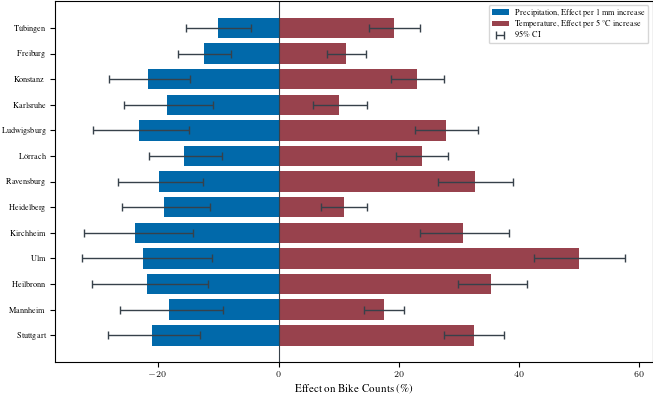

<unknown>:57: SyntaxWarning: invalid escape sequence '\%'
<unknown>:60: SyntaxWarning: invalid escape sequence '\%'


In [ ]:
from tueplots import bundles

# define colors
tue_dark = (55/255, 65/255, 74/255)
tue_red = (141/255, 45/255, 57/255)
tue_blue = (1/255, 105/255, 170/255)

plt.rcParams.update(bundles.icml2024(column="full", nrows=1, ncols=1))

# Order cities by ADFC score
cities_sorted = [
    "stuttgart",
    "mannheim",
    "heilbronn",
    "ulm",
    "kirchheim",
    "heidelberg",
    "ravensburg",
    "loerrach",
    "ludwigsburg",
    "karlsruhe",
    "konstanz",
    "freiburg",
    "tuebingen",
]

# Plot cities ordered by rain effect
cities_names = [city.capitalize().replace("oe", "ö").replace("ue", "ü").replace("ue", "ü") for city in cities_sorted]

rain_effects = np.array([rain_effects_per_mm[city] for city in cities_sorted])
temp_effects = np.array([temp_effects_per_5C[city] for city in cities_sorted])

rain_ci_lower = np.array([rain_ci_per_mm[city][0] for city in cities_sorted])
rain_ci_upper = np.array([rain_ci_per_mm[city][1] for city in cities_sorted])
temp_ci_lower = np.array([temp_ci_per_5C[city][0] for city in cities_sorted])
temp_ci_upper = np.array([temp_ci_per_5C[city][1] for city in cities_sorted])

# Build a single bar from rain effect to temp effect, split at 0
left = np.minimum(rain_effects, temp_effects)
right = np.maximum(rain_effects, temp_effects)

neg_left = left
neg_width = np.minimum(right, 0) - left
neg_width = np.maximum(neg_width, 0)

pos_left = np.maximum(left, 0)
pos_width = right - pos_left
pos_width = np.maximum(pos_width, 0)

fig, ax = plt.subplots()
ax.barh(cities_names, neg_width, left=neg_left, color=tue_blue, label=f"Precipitation, Effect per {1} mm increase")
ax.barh(cities_names, pos_width, left=pos_left, color=tue_red, alpha=0.9, label=f"Temperature, Effect per {5} °C increase")

# Error bars at rain and temp endpoints
rain_xerr = np.vstack([rain_effects - rain_ci_lower, rain_ci_upper - rain_effects])
temp_xerr = np.vstack([temp_effects - temp_ci_lower, temp_ci_upper - temp_effects])
err_rain = ax.errorbar(rain_effects, cities_names, xerr=rain_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1, label="95\% CI")
ax.errorbar(temp_effects, cities_names, xerr=temp_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1)

ax.set_xlabel("Effect on Bike Counts (\%)")
ax.axvline(0, color=tue_dark, linewidth=0.8)


ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
fig.savefig("city_ranking_prcp_and_temp_leisure.pdf", bbox_inches='tight')

In [44]:
for city in cities:
    average_bike_count_leisure = leisure_dfs[city]['bike'].mean()
    print(f"{city.capitalize()} - Average bike count during leisure hours: {average_bike_count_leisure:.2f}\n")

Loerrach - Average bike count during leisure hours: 42.80

Tuebingen - Average bike count during leisure hours: 319.86

Freiburg - Average bike count during leisure hours: 265.89

Heidelberg - Average bike count during leisure hours: 222.56

Heilbronn - Average bike count during leisure hours: 78.04

Karlsruhe - Average bike count during leisure hours: 208.88

Kirchheim - Average bike count during leisure hours: 57.29

Konstanz - Average bike count during leisure hours: 472.30

Ludwigsburg - Average bike count during leisure hours: 99.53

Ravensburg - Average bike count during leisure hours: 25.91

Stuttgart - Average bike count during leisure hours: 70.53

Ulm - Average bike count during leisure hours: 73.37

Mannheim - Average bike count during leisure hours: 110.35



# Workdays

In [45]:
# Add workhours to dataframes and run regression for workdays only
for city in cities:
    city_dfs[city]['is_workday'] = (
        (city_dfs[city]['day_of_week'] < 5) &   # Monday to Friday
        (~city_dfs[city]['is_public_holiday'])  # Not a public holiday
    ).astype(int)
    
    city_dfs[city]['is_workhour'] = (
        (city_dfs[city]['hour'] >= WORKDAY_HOURS[0]) & (city_dfs[city]['hour'] <= WORKDAY_HOURS[-1]) &
        (city_dfs[city]['is_workday'] == 1)  # Only workdays
    ).astype(int)


# Log-linear regression 
import statsmodels.api as sm
work_results = {}

work_dfs = {}
for city in cities:
    work_dfs[city] = city_dfs[city][city_dfs[city]['is_workhour'] == 1]

for city in cities:
    df = work_dfs[city].dropna(subset=['logged_bike_count', 'rain', 'temp'])

    # Build X with rain, temp, and hour dummies
    X = df[['rain', 'temp']].copy()
    X = X.astype(float)
    
    # Fixed Effects: month, year, hour
    fe_hour  = pd.get_dummies(df['hour'],  prefix='hour',  drop_first=True, dtype=float)
    fe_month = pd.get_dummies(df['month'], prefix='month', drop_first=True, dtype=float)
    
    # Combine all regressors
    X = pd.concat([X, fe_month, fe_hour], axis=1)
    
    X = sm.add_constant(X)  # Adds a constant term to the predictor
    y = df['logged_bike_count'].astype(float)
    
    model = sm.OLS(y, X).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': MAXLAGS}
    )
    work_results[city] = model
    print(f"\nLog-linear regression results for {city.capitalize()}:")
    print(model.summary())



Log-linear regression results for Loerrach:
                            OLS Regression Results                            
Dep. Variable:      logged_bike_count   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     400.9
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:59:01   Log-Likelihood:                -2428.1
No. Observations:                9703   AIC:                             4908.
Df Residuals:                    9677   BIC:                             5095.
Df Model:                          25                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const  

In [ ]:
# Extract leisure hour effects for comparison
leisure_rain_effects = {}
leisure_temp_effects = {}
leisure_rain_ci = {}
leisure_temp_ci = {}

for city in cities:
    model = results[city]
    coef = model.params
    rain_coef = coef['rain']
    temp_coef = coef['temp']
    
    rain_effect_1mm = (np.expm1(rain_coef * 1)) * 100
    temp_effect_5C = (np.expm1(temp_coef * 5)) * 100
    leisure_rain_effects[city] = rain_effect_1mm
    leisure_temp_effects[city] = temp_effect_5C
    
    # Get confidence intervals from model
    conf_int = model.conf_int(alpha=0.05)  # 95% CI
    
    # Calculate confidence intervals in effect space
    lower_rain_bound = conf_int.loc['rain', 0]
    upper_rain_bound = conf_int.loc['rain', 1]
    lower_rain_effect = (np.expm1(lower_rain_bound * 1)) * 100
    upper_rain_effect = (np.expm1(upper_rain_bound * 1)) * 100
    leisure_rain_ci[city] = (lower_rain_effect, upper_rain_effect)
    
    lower_temp_bound = conf_int.loc['temp', 0]
    upper_temp_bound = conf_int.loc['temp', 1]
    lower_temp_effect = (np.expm1(lower_temp_bound * 5)) * 100
    upper_temp_effect = (np.expm1(upper_temp_bound * 5)) * 100
    leisure_temp_ci[city] = (lower_temp_effect, upper_temp_effect)

# Extract work hour effects for comparison
work_rain_effects = {}
work_temp_effects = {}
work_rain_ci = {}
work_temp_ci = {}

for city in cities:
    model = work_results[city]
    coef = model.params
    rain_coef = coef['rain']
    temp_coef = coef['temp']
    
    rain_effect_1mm = (np.expm1(rain_coef * 1)) * 100
    temp_effect_5C = (np.expm1(temp_coef * 5)) * 100
    work_rain_effects[city] = rain_effect_1mm
    work_temp_effects[city] = temp_effect_5C
    
    # Get confidence intervals from model
    conf_int = model.conf_int(alpha=0.05)  # 95% CI
    
    # Calculate confidence intervals in effect space
    lower_rain_bound = conf_int.loc['rain', 0]
    upper_rain_bound = conf_int.loc['rain', 1]
    lower_rain_effect = (np.expm1(lower_rain_bound * 1)) * 100
    upper_rain_effect = (np.expm1(upper_rain_bound * 1)) * 100
    work_rain_ci[city] = (lower_rain_effect, upper_rain_effect)
    
    lower_temp_bound = conf_int.loc['temp', 0]
    upper_temp_bound = conf_int.loc['temp', 1]
    lower_temp_effect = (np.expm1(lower_temp_bound * 5)) * 100
    upper_temp_effect = (np.expm1(upper_temp_bound * 5)) * 100
    work_temp_ci[city] = (lower_temp_effect, upper_temp_effect)


<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:85: SyntaxWarning: invalid escape sequence '\%'
<>:52: SyntaxWarning: invalid escape sequence '\%'
<>:85: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/293597967.py:52: SyntaxWarning: invalid escape sequence '\%'
  ax1.set_xlabel("Effect on bike counts (\%)")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/293597967.py:85: SyntaxWarning: invalid escape sequence '\%'
  ax2.set_xlabel("Effect on bike counts (\%)")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/293597967.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


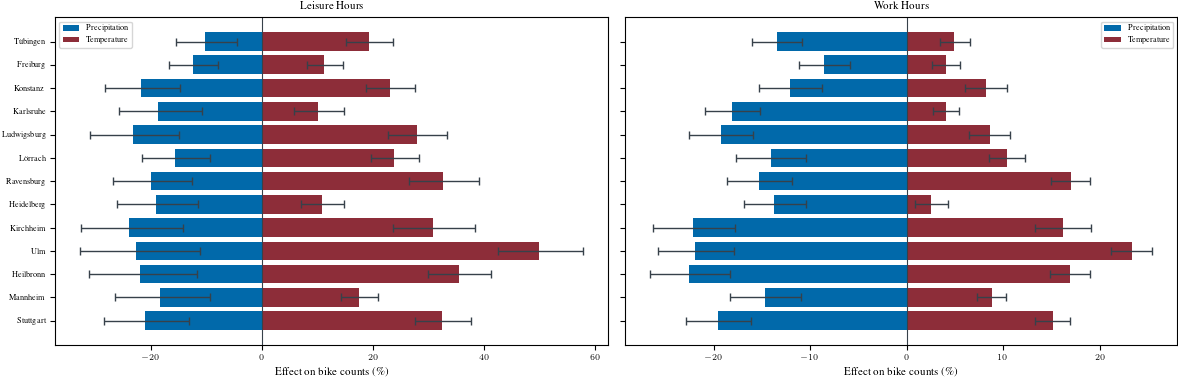

<unknown>:52: SyntaxWarning: invalid escape sequence '\%'
<unknown>:85: SyntaxWarning: invalid escape sequence '\%'


In [47]:
# Create two-subplot figure with leisure and work hours
plt.rcParams.update(bundles.icml2024(column="full", nrows=1, ncols=2))

cities_sorted = [
    "stuttgart",
    "mannheim",
    "heilbronn",
    "ulm",
    "kirchheim",
    "heidelberg",
    "ravensburg",
    "loerrach",
    "ludwigsburg",
    "karlsruhe",
    "konstanz",
    "freiburg",
    "tuebingen",
]

cities_names = [city.capitalize().replace("oe", "ö").replace("ue", "ü") for city in cities_sorted]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# LEISURE HOURS (left subplot)
leisure_rain = np.array([leisure_rain_effects[city] for city in cities_sorted])
leisure_temp = np.array([leisure_temp_effects[city] for city in cities_sorted])

leisure_rain_lower = np.array([leisure_rain_ci[city][0] for city in cities_sorted])
leisure_rain_upper = np.array([leisure_rain_ci[city][1] for city in cities_sorted])
leisure_temp_lower = np.array([leisure_temp_ci[city][0] for city in cities_sorted])
leisure_temp_upper = np.array([leisure_temp_ci[city][1] for city in cities_sorted])

left_l = np.minimum(leisure_rain, leisure_temp)
right_l = np.maximum(leisure_rain, leisure_temp)

neg_left_l = left_l
neg_width_l = np.minimum(right_l, 0) - left_l
neg_width_l = np.maximum(neg_width_l, 0)

pos_left_l = np.maximum(left_l, 0)
pos_width_l = right_l - pos_left_l
pos_width_l = np.maximum(pos_width_l, 0)

ax1.barh(cities_names, neg_width_l, left=neg_left_l, color=tue_blue, label="Precipitation")
ax1.barh(cities_names, pos_width_l, left=pos_left_l, color=tue_red, label="Temperature")

leisure_rain_xerr = np.vstack([leisure_rain - leisure_rain_lower, leisure_rain_upper - leisure_rain])
leisure_temp_xerr = np.vstack([leisure_temp - leisure_temp_lower, leisure_temp_upper - leisure_temp])
ax1.errorbar(leisure_rain, cities_names, xerr=leisure_rain_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1)
ax1.errorbar(leisure_temp, cities_names, xerr=leisure_temp_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1)

ax1.set_xlabel("Effect on bike counts (\%)")
ax1.set_title("Leisure Hours")
ax1.axvline(0, color=tue_dark, linewidth=0.8)
ax1.legend(loc="upper left")

# WORK HOURS (right subplot)
work_rain = np.array([work_rain_effects[city] for city in cities_sorted])
work_temp = np.array([work_temp_effects[city] for city in cities_sorted])

work_rain_lower = np.array([work_rain_ci[city][0] for city in cities_sorted])
work_rain_upper = np.array([work_rain_ci[city][1] for city in cities_sorted])
work_temp_lower = np.array([work_temp_ci[city][0] for city in cities_sorted])
work_temp_upper = np.array([work_temp_ci[city][1] for city in cities_sorted])

left_w = np.minimum(work_rain, work_temp)
right_w = np.maximum(work_rain, work_temp)

neg_left_w = left_w
neg_width_w = np.minimum(right_w, 0) - left_w
neg_width_w = np.maximum(neg_width_w, 0)

pos_left_w = np.maximum(left_w, 0)
pos_width_w = right_w - pos_left_w
pos_width_w = np.maximum(pos_width_w, 0)

ax2.barh(cities_names, neg_width_w, left=neg_left_w, color=tue_blue, label="Precipitation")
ax2.barh(cities_names, pos_width_w, left=pos_left_w, color=tue_red, label="Temperature")

work_rain_xerr = np.vstack([work_rain - work_rain_lower, work_rain_upper - work_rain])
work_temp_xerr = np.vstack([work_temp - work_temp_lower, work_temp_upper - work_temp])
ax2.errorbar(work_rain, cities_names, xerr=work_rain_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1)
ax2.errorbar(work_temp, cities_names, xerr=work_temp_xerr, fmt="none", ecolor=tue_dark, capsize=3, linewidth=1)

ax2.set_xlabel("Effect on bike counts (\%)")
ax2.set_title("Work Hours")
ax2.axvline(0, color=tue_dark, linewidth=0.8)
ax2.legend(loc="upper right")

# Remove y-axis labels from right subplot to avoid duplication
ax2.set_yticklabels([])

plt.tight_layout()
plt.show()

fig.savefig("city_ranking_leisure_vs_work.pdf")

<>:27: SyntaxWarning: invalid escape sequence '\%'
<>:27: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/3198529262.py:27: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Effect on Bike Counts (\%) per 1 mm Increase in Precipitation")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/3198529262.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


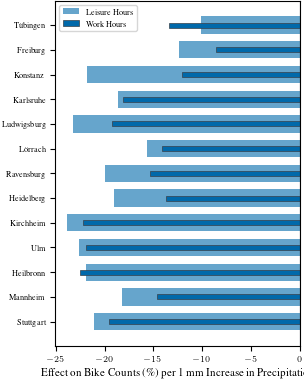

<unknown>:27: SyntaxWarning: invalid escape sequence '\%'


In [51]:
# Precipitation effects: Leisure vs Work (overlapping bars)
plt.rcParams.update(bundles.icml2024(column="half", nrows=2, ncols=1))

fig, ax = plt.subplots()

# Bar heights
bar_height_leisure = 0.7
bar_height_work = 0.2

y_pos = np.arange(len(cities_sorted))

# Leisure hours (wider bar, behind)
ax.barh(y_pos, leisure_rain, height=bar_height_leisure, color=tue_blue, alpha=0.6, label="Leisure Hours")

# Work hours (thinner bar, in front)
ax.barh(y_pos, work_rain, height=bar_height_work, color=tue_blue, alpha=1.0, label="Work Hours", edgecolor=tue_dark, linewidth=0.5)

# Error bars for both
leisure_rain_xerr = np.vstack([leisure_rain - leisure_rain_lower, leisure_rain_upper - leisure_rain])
work_rain_xerr = np.vstack([work_rain - work_rain_lower, work_rain_upper - work_rain])

# ax.errorbar(leisure_rain, y_pos + 0.15, xerr=leisure_rain_xerr, fmt="none", ecolor=tue_dark, capsize=2, linewidth=0.8, alpha=0.7)
# ax.errorbar(work_rain, y_pos - 0.15, xerr=work_rain_xerr, fmt="none", ecolor=tue_dark, capsize=2, linewidth=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(cities_names)
ax.set_xlabel("Effect on Bike Counts (\%) per 1 mm Increase in Precipitation")
ax.axvline(0, color=tue_dark, linewidth=0.8)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

fig.savefig("city_ranking_precipitation_leisure_vs_work.pdf", bbox_inches='tight')

<>:27: SyntaxWarning: invalid escape sequence '\%'
<>:27: SyntaxWarning: invalid escape sequence '\%'
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/3695316423.py:27: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Effect on Bike Counts (\%) per 5 °C Increase in Temperature")
/var/folders/zk/59vcdjbd7vgfyrj4tht5rfkw0000gn/T/ipykernel_44822/3695316423.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


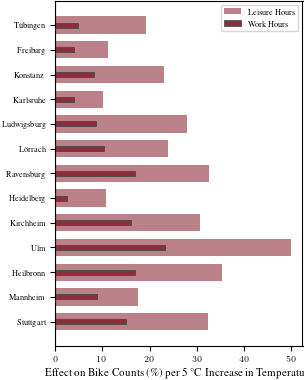

<unknown>:27: SyntaxWarning: invalid escape sequence '\%'


In [54]:
# Temperature effects: Leisure vs Work (overlapping bars)
plt.rcParams.update(bundles.icml2024(column="half", nrows=2, ncols=1))

fig, ax = plt.subplots()

# Bar heights
bar_height_leisure = 0.7
bar_height_work = 0.2

y_pos = np.arange(len(cities_sorted))

# Leisure hours (wider bar, behind)
ax.barh(y_pos, leisure_temp, height=bar_height_leisure, color=tue_red, alpha=0.6, label="Leisure Hours")

# Work hours (thinner bar, in front)
ax.barh(y_pos, work_temp, height=bar_height_work, color=tue_red, alpha=1.0, label="Work Hours", edgecolor=tue_dark, linewidth=0.5)

# Error bars for both
leisure_temp_xerr = np.vstack([leisure_temp - leisure_temp_lower, leisure_temp_upper - leisure_temp])
work_temp_xerr = np.vstack([work_temp - work_temp_lower, work_temp_upper - work_temp])

# ax.errorbar(leisure_temp, y_pos + 0.15, xerr=leisure_temp_xerr, fmt="none", ecolor=tue_dark, capsize=2, linewidth=0.8, alpha=0.7)
# ax.errorbar(work_temp, y_pos - 0.15, xerr=work_temp_xerr, fmt="none", ecolor=tue_dark, capsize=2, linewidth=0.8)

ax.set_yticks(y_pos)
ax.set_yticklabels(cities_names)
ax.set_xlabel("Effect on Bike Counts (\%) per 5 °C Increase in Temperature")
ax.axvline(0, color=tue_dark, linewidth=0.8)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

fig.savefig("city_ranking_temperature_leisure_vs_work.pdf", bbox_inches='tight')

In [57]:
# Investigate the 5 AM spike on leisure days
print("Leisure days (weekends) - Data points per hour:")
leisure_no_rain_counts = leisure_days[leisure_days['rain'] == 0].groupby('hour')['bike'].count()
print("\nNo rain:")
for h in range(24):
    print(f"  {h:02d}:00 - {leisure_no_rain_counts.get(h, 0)} observations")

print(f"\n\nLight rain ({RAIN_INTERVAL[0]}-{RAIN_INTERVAL[1]} mm):")
leisure_light_rain_counts = leisure_days[(leisure_days['rain'] >= RAIN_INTERVAL[0]) & (leisure_days['rain'] <= RAIN_INTERVAL[1])].groupby('hour')['bike'].count()
for h in range(24):
    print(f"  {h:02d}:00 - {leisure_light_rain_counts.get(h, 0)} observations")

Leisure days (weekends) - Data points per hour:

No rain:
  00:00 - 265 observations
  01:00 - 263 observations
  02:00 - 259 observations
  03:00 - 262 observations
  04:00 - 271 observations
  05:00 - 271 observations
  06:00 - 272 observations
  07:00 - 277 observations
  08:00 - 269 observations
  09:00 - 259 observations
  10:00 - 248 observations
  11:00 - 251 observations
  12:00 - 246 observations
  13:00 - 241 observations
  14:00 - 241 observations
  15:00 - 241 observations
  16:00 - 254 observations
  17:00 - 257 observations
  18:00 - 256 observations
  19:00 - 266 observations
  20:00 - 266 observations
  21:00 - 268 observations
  22:00 - 270 observations
  23:00 - 268 observations


NameError: name 'RAIN_INTERVAL' is not defined

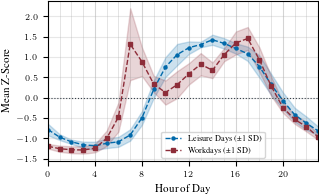


Pooled z-score statistics (all cities combined):

Work days - Peak hours:
  Morning (7-9 AM): mean z-score = 0.85, pooled std = 0.48
  Evening (17-18): mean z-score = 1.20, pooled std = 0.29

Pooled std interpretation: Larger values indicate more variability in hourly patterns across all cities

Leisure days - Peak hours:
  Afternoon (12-17): mean z-score = 1.27, pooled std = 0.13


In [71]:
# Pooled z-score analysis: Combine all cities' z-scores into one distribution
# This shows the overall variability of z-scored patterns across ALL data points
plt.rcParams.update(bundles.icml2024(column="half", nrows=2, ncols=2))


hours = np.arange(24)

# Collect ALL z-scored data points for each hour (pooled across cities)
leisure_pooled_by_hour = {h: [] for h in range(24)}
work_pooled_by_hour = {h: [] for h in range(24)}

for city in cities:
    city_df = city_dfs[city].copy()
    
    # Filter by day type
    leisure_days = city_df[(city_df['day_of_week'] >= 5) | (city_df['is_public_holiday'] == 1)]
    work_days = city_df[(city_df['day_of_week'] < 5) & (city_df['is_public_holiday'] == 0)]
    
    # Calculate hourly averages for this city
    leisure_mean = leisure_days.groupby('hour')['bike'].mean()
    work_mean = work_days.groupby('hour')['bike'].mean()
    
    # Z-score normalize: (x - mean) / std across all hours
    leisure_zscore = (leisure_mean - leisure_mean.mean()) / leisure_mean.std()
    work_zscore = (work_mean - work_mean.mean()) / work_mean.std()
    
    # Add each city's z-scores to the pooled distribution
    for h in range(24):
        if h in leisure_zscore.index:
            leisure_pooled_by_hour[h].append(leisure_zscore.loc[h])
        if h in work_zscore.index:
            work_pooled_by_hour[h].append(work_zscore.loc[h])

# Calculate mean and std of the pooled distribution for each hour
leisure_pooled_mean = np.array([np.mean(leisure_pooled_by_hour[h]) for h in range(24)])
leisure_pooled_std = np.array([np.std(leisure_pooled_by_hour[h]) for h in range(24)])
work_pooled_mean = np.array([np.mean(work_pooled_by_hour[h]) for h in range(24)])
work_pooled_std = np.array([np.std(work_pooled_by_hour[h]) for h in range(24)])

fig, ax = plt.subplots()

# Plot leisure days
ax.plot(hours, leisure_pooled_mean, color=tue_blue, linewidth=1, linestyle='--', 
        marker='o', markersize=2.2, label="Leisure Days (±1 SD)")
ax.fill_between(hours, 
                leisure_pooled_mean - leisure_pooled_std, 
                leisure_pooled_mean + leisure_pooled_std, 
                alpha=0.2, color=tue_blue)

# Plot work days
ax.plot(hours, work_pooled_mean, color=tue_red, linewidth=1, linestyle='--', 
        marker='s', markersize=2.2, label="Workdays (±1 SD)")
ax.fill_between(hours, 
                work_pooled_mean - work_pooled_std, 
                work_pooled_mean + work_pooled_std, 
                alpha=0.2, color=tue_red)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Z-Score")
ax.set_xticks([0, 4, 8, 12, 16, 20])
ax.set_xlim(0, 23)
ax.axhline(0, color=tue_dark, linewidth=0.8, linestyle=':')

ax.legend(loc=(0.42, 0.02))
ax.grid(True, alpha=0.3)
# Add vertical lines at all whole numbers
for h in range(24):
    ax.axvline(h, color='gray', linewidth=0.5, alpha=0.3, zorder=0)

plt.show()

fig.savefig("all_cities_zscore_hourly_leisure_vs_work.pdf", bbox_inches='tight')


# Print statistics
print("\nPooled z-score statistics (all cities combined):")
print(f"\nWork days - Peak hours:")
print(f"  Morning (7-9 AM): mean z-score = {work_pooled_mean[[7, 8, 9]].mean():.2f}, pooled std = {work_pooled_std[[7, 8, 9]].mean():.2f}")
print(f"  Evening (17-18): mean z-score = {work_pooled_mean[[17, 18]].mean():.2f}, pooled std = {work_pooled_std[[17, 18]].mean():.2f}")
print(f"\nPooled std interpretation: Larger values indicate more variability in hourly patterns across all cities")
print(f"\nLeisure days - Peak hours:")
print(f"  Afternoon (12-17): mean z-score = {leisure_pooled_mean[list(range(12, 18))].mean():.2f}, pooled std = {leisure_pooled_std[list(range(12, 18))].mean():.2f}")